:::note info
**この記事の対象者**

* Pythonの基本文法を理解している方
* pandas、NumPy、Matplotlibなどを学んだ方
* Pythonを土木工学の計算に活用してみたい方
* 構造力学の基本をPythonで扱ってみたい方
:::
:::note warn
**この記事を読む前に**

* 本記事は筆者個人の学習記録であり、所属する大学や特定の団体の公式見解ではありません。
* 本記事の内容には十分注意を払っていますが、正確性や完全性を保証するものではありません。
* 本記事を参考にする場合は、必ずご自身でも教科書、設計基準、最新の公式資料等をご確認ください。
* 本記事で扱う計算は学習を目的とした簡略化されたモデルです。実務上の設計・安全性の判断には使用しないでください。
* 実務での構造設計には、関係法令、設計基準、荷重条件、材料特性、施工条件などを含めた専門的な検討が必要です。
:::

これまでの記事一覧はこちらから

[https://qiita.com/skyblueao77/items/ea31e9890f6368b25e19](https://qiita.com/skyblueao77/items/ea31e9890f6368b25e19)

この連載のGitHubリポジトリはこちら

[https://github.com/skyblueao77/civil-engineering-python](https://github.com/skyblueao77/civil-engineering-python)

## はじめに

これまでの記事では、Pythonの基本文法から始め、pandasによるデータ処理、Matplotlibによる可視化、NumPy・SciPyによる数値計算、GeoPandasによる地理空間データの扱いについて学んできました。

ここまでで、Pythonを使って「データを処理する」「計算する」「可視化する」といった基本的な技術を身につけてきました。

今回からは、これらの知識を実際の土木工学の問題に適用していきます。

今回の題材は、構造力学で基本となる **単純支持梁** です。

梁は、橋梁や建築物などさまざまな構造物を理解する上で重要な部材です。

今回は、単純支持梁に等分布荷重が作用する問題を取り上げ、

* 支点反力
* せん断力
* 曲げモーメント
* たわみ

を理論式から求め、それをPythonで計算・可視化してみます。

さらに、最後には梁の長さや荷重、材料特性などの条件を変更しながら、多数のケースをPythonで自動計算してみます。

今回作成する計算モデルは、今後の記事でも再び利用する予定です。

---

# 1. 今回扱う問題

今回は、次のような単純支持梁を考えます。

```text
      等分布荷重 q
  ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
  ─────────────────
 ▲                 ▲
 A                 B
 │←────── L ──────→│
```

梁の長さを `L`、等分布荷重を `q` とします。

また、梁の材料特性としてヤング係数 `E`、断面特性として断面二次モーメント `I` を使用します。

今回は単純支持梁を扱いますが、解析対象そのものもPythonで描いてみましょう。

Matplotlibはグラフを描くだけでなく、線や記号、矢印などを組み合わせて簡単な構造モデルを表現することもできます。

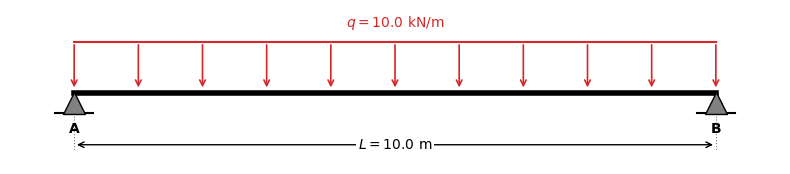

In [1]:
import matplotlib.pyplot as plt
import numpy as np

L = 10.0
q = 10.0

fig, ax = plt.subplots(figsize=(8, 2.5))

# 1. 梁
ax.plot([0, L], [0, 0], color="black", linewidth=4, zorder=2)

# 2. 支点 (マーカーの重心を下げて、頂点を梁の下面 y=0 に合わせる)
ax.scatter([0, L], [-0.15, -0.15], marker="^", s=250, color="gray", edgecolors="black", zorder=3)
ax.plot([-0.3, 0.3], [-0.3, -0.3], color="black", lw=1.5)       # Aの地面
ax.plot([L - 0.3, L + 0.3], [-0.3, -0.3], color="black", lw=1.5)  # Bの地面

# 3. 等分布荷重 (上部バー + 矢印)
load_h = 0.8
ax.plot([0, L], [load_h, load_h], color="tab:red", lw=1.5)
for xi in np.linspace(0, L, 11):
    ax.annotate("", xy=(xi, 0.05), xytext=(xi, load_h),
                arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.2, mutation_scale=10))

# 4. ラベル・寸法線
ax.text(L / 2, load_h + 0.15, rf"$q = {q:.1f}\ \mathrm{{kN/m}}$", ha="center", va="bottom", color="tab:red")
ax.text(0, -0.45, "A", ha="center", va="top", fontweight="bold")
ax.text(L, -0.45, "B", ha="center", va="top", fontweight="bold")

# 寸法線
dim_y = -0.8
ax.annotate("", xy=(0, dim_y), xytext=(L, dim_y), arrowprops=dict(arrowstyle="<->", color="black"))
ax.plot([0, 0], [-0.35, dim_y - 0.1], color="gray", ls=":", lw=0.8)
ax.plot([L, L], [-0.35, dim_y - 0.1], color="gray", ls=":", lw=0.8)
ax.text(L / 2, dim_y, rf"$L = {L:.1f}\ \mathrm{{m}}$", ha="center", va="center",
        bbox=dict(fc="white", ec="none", pad=1.5))

# 描画範囲
ax.set_xlim(-1.0, L + 1.0)
ax.set_ylim(-1.1, load_h + 0.5)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

実行すると、梁・支点・等分布荷重を描画できます。

このモデルを使って、ここから支点反力、せん断力、曲げモーメント、たわみを順番に求めていきます。

今回の主な入力値は次の4つです。

| 変数  | 意味         | 例           |
| --- | --------- | ----------- |
| `L` | 梁の長さ      | 10 m        |
| `q` | 等分布荷重     | 10 kN/m     |
| `E` | ヤング係数     | 200 GPa     |
| `I` | 断面二次モーメント | 8.0×10⁻⁵ m⁴ |

なお、単位系は一貫させる必要があります。

ここでは計算を分かりやすくするため、SI単位系を使用します。

例えば、

```text
長さ      → m
荷重      → N/m
ヤング係数 → Pa
断面二次モーメント → m⁴
```

とします。

---

# 2. 今回の梁モデルの仮定

実際の梁は非常に複雑な挙動をしますが、今回は学習を目的としてモデルを簡略化します。

主な仮定は次のとおりです。

* 梁は単純支持されている
* 荷重は等分布荷重である
* 梁は一様断面である
* 材料は線形弾性体として扱う
* 変形は小さい
* Euler-Bernoulli梁理論を用いる
* せん断変形は考慮しない

このような仮定を置くことで、梁の挙動を比較的簡単な式で表現できます。

実際の構造物では、荷重条件、断面形状、材料非線形性、座屈、せん断変形など、さらに多くの要素を考慮する必要があります。

今回の目的は実構造物の設計ではなく、

> **構造力学の問題をPythonでどのように計算するのか**

を理解することです。

---

# 3. 支点反力を求める

まず、支点A、Bに生じる反力を求めます。

梁全体に作用する等分布荷重の合力は、$qL$ です。

等分布荷重は梁の中央に作用すると考えられるため、左右対称な単純梁では支点反力も等しくなります。

したがって、

$$R_A=R_B=\frac{qL}{2}$$

となります。

例えば、

```text
L = 10 m
q = 10 kN/m
```

なら、

$$R_A=R_B=\frac{10\times10}{2}=50\ \mathrm{kN}$$

となります。

Pythonでも計算してみましょう。

In [2]:
L = 10.0
q = 10_000.0

RA = q * L / 2
RB = q * L / 2

print(f"支点Aの反力: {RA / 1000:.1f} kN")
print(f"支点Bの反力: {RB / 1000:.1f} kN")

支点Aの反力: 50.0 kN
支点Bの反力: 50.0 kN


---

# 4. せん断力を求める

次に、梁の位置 `x` におけるせん断力を考えます。

支点Aから距離 `x` の位置で梁を切断すると、左側には支点反力 $R_A$ と、その区間に作用する等分布荷重があります。

今回の符号規約では、せん断力を

$$V(x)=R_A-qx$$

とします。

支点反力 $R_A=\frac{qL}{2}$ を代入すると、

$$V(x)=\frac{qL}{2}-qx$$

となります。

例えば中央部 $x=L/2$ では、$V\left(\frac{L}{2}\right)=0$ となります。

Pythonでは次のように計算できます。

In [3]:
import numpy as np

L = 10.0
q = 10_000.0

x = np.linspace(0, L, 501)

V = q * L / 2 - q * x

ここで `np.linspace()` を使用して、梁の左端から右端までの位置を501点生成しています。501点とすることで、今回の条件では梁中央 x=L/2 も計算点に含まれます。

これは、これまでNumPyで学んできた配列計算がそのまま構造力学の計算に利用されている例です。

---

# 5. 曲げモーメントを求める

次に曲げモーメントを求めます。

支点Aから距離 `x` の位置における曲げモーメントは、

$$M(x)=R_Ax-\frac{qx^2}{2}$$

です。

支点反力を代入すると、

$$M(x)=\frac{qL}{2}x-\frac{q}{2}x^2$$

となります。

支点では曲げモーメントが0になります。$M(0)=0$、また $M(L)=0$ です。

最大曲げモーメントは梁の中央で発生します。$x=\frac{L}{2}$ を代入すると、

$$M_{\max}=\frac{qL^2}{8}$$

となります。

例えば、

```text
L = 10 m
q = 10 kN/m
```

なら、

$$M_{\max}=\frac{10\times10^2}{8}=125\ \mathrm{kN\cdot m}$$

となります。

Pythonでは、次のように計算できます。

In [4]:
M = q * L * x / 2 - q * x**2 / 2

M_max = q * L**2 / 8

print(f"最大曲げモーメント: {M_max / 1000:.1f} kN·m")

最大曲げモーメント: 125.0 kN·m


---

# 6. たわみを求める

ここからが今回の重要な部分です。

梁に荷重が作用すると、梁は変形します。この変形量を **たわみ** と呼びます。

Euler-Bernoulli梁理論では、梁の曲げモーメントとたわみ曲線の曲率には関係があります。

今回は、**たわみ `w` は下向きを正、曲げモーメント `M` は正曲げ（サギング）を正**として扱います。

この符号規約では、

$$EI\frac{d^2w}{dx^2}=-M(x)$$

となります。

ここで `EI` は梁の曲げ剛性です。

なお、たわみや曲げモーメントの符号は、座標軸や正方向の定義によって変わります。そのため、教科書や資料によって式の符号が異なる場合があります。

単純支持梁に等分布荷重 `q` が作用する場合、たわみは、

$$w(x)=\frac{q}{24EI}\left(x^4-2Lx^3+L^3x\right)$$

と表せます。

ここで、
* `E`：ヤング係数
* `I`：断面二次モーメント

です。

また、中央部における最大たわみは、

$$\delta_{\max}=\frac{5qL^4}{384EI}$$

となります。

この式から、梁の長さ `L` が非常に重要であることが分かります。

最大たわみは、$\delta_{\max}\propto L^4$ に比例します。

つまり、他の条件を一定とすると、梁の長さが2倍になると最大たわみは16倍になります。

これは、後ほどPythonで実際に確認してみます。

---

# 7. Pythonで梁全体を計算する

ここまでの式をPythonにまとめてみましょう。

In [5]:
import numpy as np

# 梁の条件
L = 10.0             # 梁の長さ [m]
q = 10_000.0         # 等分布荷重 [N/m]
E = 200e9            # ヤング係数 [Pa]
I = 8.0e-5           # 断面二次モーメント [m^4]

# 梁上の位置
x = np.linspace(0, L, 501)

# 支点反力
RA = q * L / 2
RB = q * L / 2

# せん断力
V = RA - q * x

# 曲げモーメント
M = RA * x - q * x**2 / 2

# たわみ
w = q / (24 * E * I) * (
    x**4 - 2 * L * x**3 + L**3 * x
)

# 最大曲げモーメント
M_max = q * L**2 / 8

# 最大たわみ
delta_max = 5 * q * L**4 / (384 * E * I)

print(f"支点反力 RA: {RA / 1000:.2f} kN")
print(f"支点反力 RB: {RB / 1000:.2f} kN")
print(f"最大曲げモーメント: {M_max / 1000:.2f} kN·m")
print(f"最大たわみ: {delta_max * 1000:.4f} mm")

支点反力 RA: 50.00 kN
支点反力 RB: 50.00 kN
最大曲げモーメント: 125.00 kN·m
最大たわみ: 81.3802 mm


ここで重要なのは、`x` がNumPy配列になっていることです。

そのため、`V = RA - q * x` のように書くだけで、501個の位置について一度にせん断力を計算できます。

これがNumPyを土木工学の計算に利用する大きなメリットの一つです。

---

# 8. Matplotlibでせん断力図・曲げモーメント図・たわみを可視化する

計算しただけでは、梁の挙動を直感的に理解するのが難しい場合があります。

そこで、これまで学んできたMatplotlibを利用して可視化してみましょう。

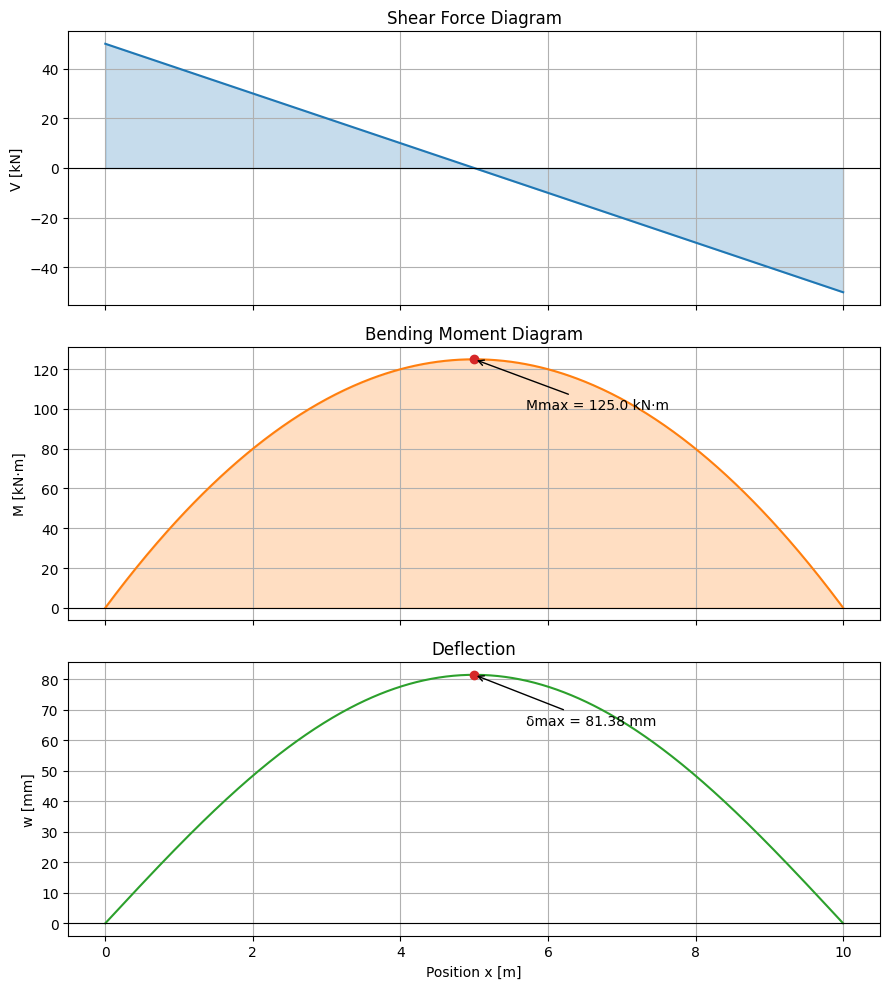

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True,
)

# せん断力図
axes[0].plot(
    x,
    V / 1000,
    color="tab:blue",
)
axes[0].fill_between(
    x,
    V / 1000,
    0,
    alpha=0.25,
    color="tab:blue",
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("V [kN]")
axes[0].set_title("Shear Force Diagram")
axes[0].grid(True)

# 曲げモーメント図
axes[1].plot(
    x,
    M / 1000,
    color="tab:orange",
)
axes[1].fill_between(
    x,
    M / 1000,
    0,
    alpha=0.25,
    color="tab:orange",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("M [kN·m]")
axes[1].set_title("Bending Moment Diagram")
axes[1].grid(True)

# 最大曲げモーメントを表示
x_mid = L / 2

axes[1].scatter(
    x_mid,
    M_max / 1000,
    color="tab:red",
    zorder=3,
)

axes[1].annotate(
    f"Mmax = {M_max / 1000:.1f} kN·m",
    xy=(x_mid, M_max / 1000),
    xytext=(x_mid + 0.7, M_max / 1000 * 0.8),
    arrowprops=dict(arrowstyle="->"),
)

# たわみ図
axes[2].plot(
    x,
    w * 1000,
    color="tab:green",
)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("Position x [m]")
axes[2].set_ylabel("w [mm]")
axes[2].set_title("Deflection")
axes[2].grid(True)

# 最大たわみを表示
axes[2].scatter(
    x_mid,
    delta_max * 1000,
    color="tab:red",
    zorder=3,
)

axes[2].annotate(
    f"δmax = {delta_max * 1000:.2f} mm",
    xy=(x_mid, delta_max * 1000),
    xytext=(x_mid + 0.7, delta_max * 1000 * 0.8),
    arrowprops=dict(arrowstyle="->"),
)

plt.tight_layout()
plt.show()

ここでは、3つのグラフを縦に並べています。上から、1. せん断力、2. 曲げモーメント、3. たわみ です。

このように、これまで学んできたNumPyとMatplotlibを組み合わせることで、構造力学の計算結果を視覚的に確認できます。

グラフを見ると、せん断力は梁の中央で0となり、曲げモーメントは中央で最大となっていることが分かります。
また、たわみも左右対称となり、梁の中央で最大となっています。

このように可視化することで、前の章で求めた理論式が梁のどの位置でどのような値になるのかを直感的に把握できます。

---

# 9. 計算結果を確認する

ここで、計算結果が構造力学の理論と一致しているか確認してみましょう。

プログラムでは「グラフがそれらしく見える」だけで正しいとは限りません。
そこで、境界条件や理論上分かっている値を使って計算結果を検証します。

例えば、
* 支点Aの反力 = 支点Bの反力
* $M(0) = 0$, $M(L) = 0$
* 中央部で $V(L/2) = 0$

となっているでしょうか。Pythonで確認してみます。

In [7]:
M_left = M[0]
M_right = M[-1]
V_mid = np.interp(L / 2, x, V)

print(
    "M(0) ≈ 0:",
    np.isclose(M_left, 0),
)

print(
    "M(L) ≈ 0:",
    np.isclose(M_right, 0),
)

print(
    "V(L/2) ≈ 0:",
    np.isclose(V_mid, 0, atol=1e-10),
)

# 理論式から求めた最大値
M_max_theory = q * L**2 / 8
delta_max_theory = 5 * q * L**4 / (384 * E * I)

# NumPy配列から求めた最大値
M_max_numerical = np.max(M)
delta_max_numerical = np.max(w)

print(
    "最大曲げモーメント:",
    np.isclose(
        M_max_theory,
        M_max_numerical,
        rtol=1e-4,
    ),
)

print(
    "最大たわみ:",
    np.isclose(
        delta_max_theory,
        delta_max_numerical,
        rtol=1e-4,
    ),
)

M(0) ≈ 0: True
M(L) ≈ 0: True
V(L/2) ≈ 0: True
最大曲げモーメント: True
最大たわみ: True


ここでは、理論式から直接求めた最大値と、NumPy配列から取得した最大値についても比較しています。

解析式と数値計算の結果が一致していることを確認することで、プログラムの実装が理論式を正しく反映しているかをチェックできます。

今回は**501点で計算しているため、梁中央 x=L/2 も計算点に含まれています**。そのため、理論式から求めた最大値とNumPy配列から求めた最大値が一致することを確認できます。

このように、プログラムがエラーなく実行できることだけでなく、

> **計算結果が力学的に正しいか**

を確認することが重要です。これは、土木工学でPythonを利用するときに特に意識したいポイントです。

---

# 10. 梁の条件を変えてみる

ここまででは、1つの梁について計算しました。しかし、Pythonを使うメリットは、条件を簡単に変更して計算できることです。

例えば梁の長さ `L` を変更してみましょう。

最大たわみは $\delta_{\max}=\frac{5qL^4}{384EI}$ なので、梁の長さを変えれば結果も変化します。

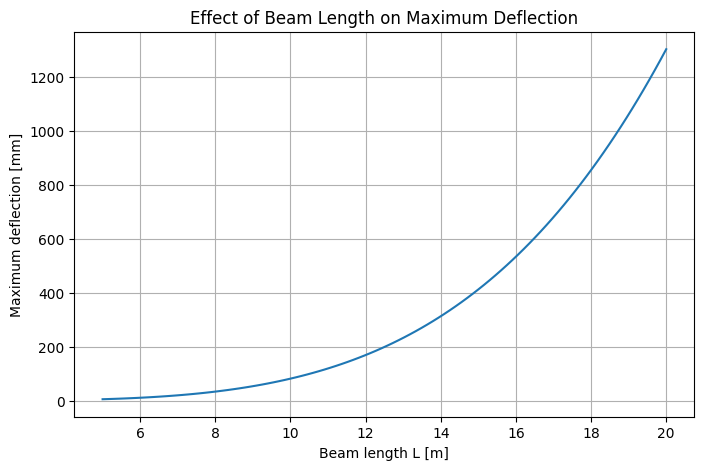

In [8]:
lengths = np.linspace(5, 20, 100)

deflections = (
    5 * q * lengths**4
    / (384 * E * I)
)

plt.figure(figsize=(8, 5))

plt.plot(
    lengths,
    deflections * 1000,
    color="tab:blue",
)

plt.xlabel("Beam length L [m]")
plt.ylabel("Maximum deflection [mm]")
plt.title("Effect of Beam Length on Maximum Deflection")
plt.grid(True)

plt.show()

梁の長さが増えるにつれて、最大たわみが急激に増加することが分かります。

---

# 11. 荷重を変えてみる

次に、等分布荷重 `q` を変更してみます。

In [9]:
loads = np.array([5_000, 10_000, 20_000, 40_000])

for q_test in loads:
    delta = 5 * q_test * L**4 / (384 * E * I)
    print(
        f"q = {q_test / 1000:>5.1f} kN/m : "
        f"最大たわみ = {delta * 1000:.4f} mm"
    )

q =   5.0 kN/m : 最大たわみ = 40.6901 mm
q =  10.0 kN/m : 最大たわみ = 81.3802 mm
q =  20.0 kN/m : 最大たわみ = 162.7604 mm
q =  40.0 kN/m : 最大たわみ = 325.5208 mm


最大たわみは $\delta_{\max}\propto q$ なので、荷重が2倍になれば最大たわみも2倍になります。

このように、理論式から予想した関係をPythonで実際に確認できます。

---

# 12. ヤング係数を変えてみる

材料の硬さを表す代表的な値がヤング係数 `E` です。

最大たわみは $\delta_{\max}\propto\frac{1}{E}$ なので、ヤング係数が大きいほどたわみは小さくなります。

In [10]:
youngs_moduli = np.array([
    100e9,
    150e9,
    200e9,
    250e9,
])

for E_test in youngs_moduli:
    delta = 5 * q * L**4 / (384 * E_test * I)
    print(
        f"E = {E_test / 1e9:>5.0f} GPa : "
        f"最大たわみ = {delta * 1000:.4f} mm"
    )

E =   100 GPa : 最大たわみ = 162.7604 mm
E =   150 GPa : 最大たわみ = 108.5069 mm
E =   200 GPa : 最大たわみ = 81.3802 mm
E =   250 GPa : 最大たわみ = 65.1042 mm


ここでも、「材料特性 → 梁の応答」という関係をPythonで確認できます。

---

# 13. 断面二次モーメントを変えてみる

最後に、断面二次モーメント `I` を変更してみます。

最大たわみは $\delta_{\max}\propto\frac{1}{I}$ なので、断面二次モーメントが大きいほど梁は曲げに対して変形しにくくなります。

In [11]:
moments_of_inertia = np.array([
    4.0e-5,
    8.0e-5,
    1.6e-4,
    3.2e-4,
])

for I_test in moments_of_inertia:
    delta = 5 * q * L**4 / (384 * E * I_test)
    print(
        f"I = {I_test:.2e} m^4 : "
        f"最大たわみ = {delta * 1000:.4f} mm"
    )

I = 4.00e-05 m^4 : 最大たわみ = 162.7604 mm
I = 8.00e-05 m^4 : 最大たわみ = 81.3802 mm
I = 1.60e-04 m^4 : 最大たわみ = 40.6901 mm
I = 3.20e-04 m^4 : 最大たわみ = 20.3451 mm


このように、梁の応答が

```text
梁の長さ L
荷重 q
ヤング係数 E
断面二次モーメント I
        ↓
    梁の力学モデル
        ↓
最大たわみ δmax
```

という関係で決まっていることが分かります。

## 各パラメータの影響をグラフで比較する

ここまで確認した `L`、`q`、`E`、`I` と最大たわみの関係を、グラフにまとめて比較してみます。

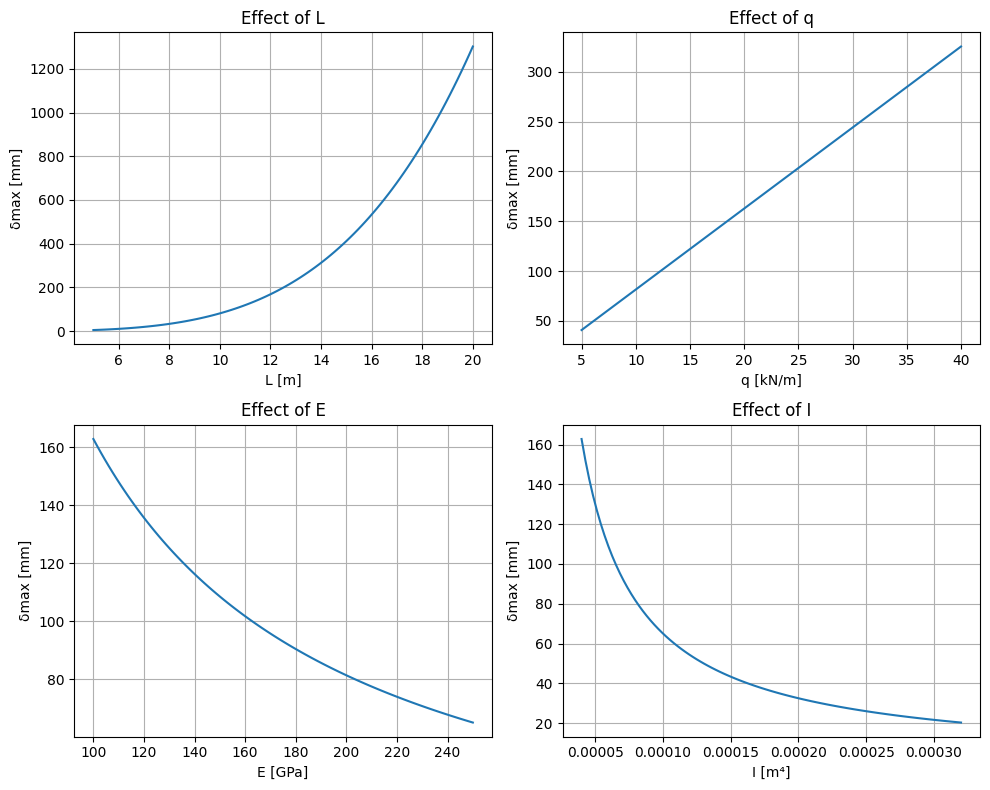

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# L
L_values = np.linspace(5, 20, 100)
delta_L = 5 * q * L_values**4 / (384 * E * I)

axes[0, 0].plot(L_values, delta_L * 1000)
axes[0, 0].set_xlabel("L [m]")
axes[0, 0].set_ylabel("δmax [mm]")
axes[0, 0].set_title("Effect of L")

# q
q_values = np.linspace(5_000, 40_000, 100)
delta_q = 5 * q_values * L**4 / (384 * E * I)

axes[0, 1].plot(q_values / 1000, delta_q * 1000)
axes[0, 1].set_xlabel("q [kN/m]")
axes[0, 1].set_ylabel("δmax [mm]")
axes[0, 1].set_title("Effect of q")

# E
E_values = np.linspace(100e9, 250e9, 100)
delta_E = 5 * q * L**4 / (384 * E_values * I)

axes[1, 0].plot(E_values / 1e9, delta_E * 1000)
axes[1, 0].set_xlabel("E [GPa]")
axes[1, 0].set_ylabel("δmax [mm]")
axes[1, 0].set_title("Effect of E")

# I
I_values = np.linspace(4.0e-5, 3.2e-4, 100)
delta_I = 5 * q * L**4 / (384 * E * I_values)

axes[1, 1].plot(I_values, delta_I * 1000)
axes[1, 1].set_xlabel("I [m⁴]")
axes[1, 1].set_ylabel("δmax [mm]")
axes[1, 1].set_title("Effect of I")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

グラフを比較すると、q は最大たわみに比例し、E と I は大きくなるほど最大たわみを小さくします。特に L は4乗で影響するため、梁の長さによる変化が非常に大きいことが分かります。

---

# 14. 計算を関数にまとめる

ここまでの計算を、1つの関数にまとめてみましょう。

In [13]:
def beam_response(L, q, E, I, x):
    """
    単純支持梁・等分布荷重の応答を計算する。

    Parameters
    ----------
    L : float
        梁の長さ [m]
    q : float
        等分布荷重 [N/m]
    E : float
        ヤング係数 [Pa]
    I : float
        断面二次モーメント [m^4]
    x : numpy.ndarray
        梁上の位置 [m]

    Returns
    -------
    V : numpy.ndarray
        せん断力 [N]
    M : numpy.ndarray
        曲げモーメント [N·m]
    w : numpy.ndarray
        たわみ [m]
    """
    RA = q * L / 2

    V = RA - q * x
    M = RA * x - q * x**2 / 2
    w = q / (24 * E * I) * (
        x**4 - 2 * L * x**3 + L**3 * x
    )

    return V, M, w

これで、次のように呼び出せます。

In [14]:
x = np.linspace(0, L, 501)

V, M, w = beam_response(
    L=L,
    q=q,
    E=E,
    I=I,
    x=x,
)

関数にまとめることで、条件を変更しても同じ計算処理を何度も利用できます。

これは今後の連載で重要になります。

---

# 15. 多数の条件を自動計算する

ここまで来ると、Pythonの強みがさらに分かりやすくなります。

例えば、梁の長さ、荷重、ヤング係数、断面二次モーメントを変更して、多数のケースを自動的に計算できます。

まず、最大たわみだけを計算する関数を作ります。

In [15]:
def max_deflection(L, q, E, I):
    return 5 * q * L**4 / (384 * E * I)

そして、複数の条件を計算してみます。

In [16]:
cases = [
    (5.0, 5_000.0, 200e9, 8.0e-5),
    (10.0, 10_000.0, 200e9, 8.0e-5),
    (15.0, 10_000.0, 200e9, 8.0e-5),
    (20.0, 20_000.0, 200e9, 8.0e-5),
]

for L_case, q_case, E_case, I_case in cases:
    delta = max_deflection(
        L_case,
        q_case,
        E_case,
        I_case,
    )

    print(
        f"L={L_case:>4.1f} m, "
        f"q={q_case / 1000:>5.1f} kN/m, "
        f"E={E_case / 1e9:>5.0f} GPa, "
        f"I={I_case:.2e} m^4 "
        f"→ δmax={delta * 1000:.4f} mm"
    )

L= 5.0 m, q=  5.0 kN/m, E=  200 GPa, I=8.00e-05 m^4 → δmax=2.5431 mm
L=10.0 m, q= 10.0 kN/m, E=  200 GPa, I=8.00e-05 m^4 → δmax=81.3802 mm
L=15.0 m, q= 10.0 kN/m, E=  200 GPa, I=8.00e-05 m^4 → δmax=411.9873 mm
L=20.0 m, q= 20.0 kN/m, E=  200 GPa, I=8.00e-05 m^4 → δmax=2604.1667 mm


このように、手計算では一つずつ計算する必要があるケースでも、Pythonなら条件をまとめて処理できます。

さらにケース数を100、1000、10000と増やしても、基本的には同じ考え方で自動計算できます。

ここで計算した結果を表形式にまとめてみましょう。

In [17]:
import pandas as pd

results = []

for L_case, q_case, E_case, I_case in cases:
    delta = max_deflection(
        L_case, q_case, E_case, I_case
    )

    results.append({
        "L [m]": L_case,
        "q [kN/m]": q_case / 1000,
        "E [GPa]": E_case / 1e9,
        "I [m^4]": I_case,
        "delta_max [mm]": delta * 1000,
    })

df = pd.DataFrame(results)
df

,L [m],q [kN/m],E [GPa],I [m^4],delta_max [mm]
0,5.0,5.0,200.0,0.00008,2.543132
1,10.0,10.0,200.0,0.00008,81.380208
2,15.0,10.0,200.0,0.00008,411.987305
3,20.0,20.0,200.0,0.00008,2604.166667


---

# 16. 今回の計算モデルを整理する

今回扱った問題を整理すると、次のようになります。

```text
入力
│
├─ 梁の長さ L
├─ 等分布荷重 q
├─ ヤング係数 E
└─ 断面二次モーメント I
        │
        ↓
  構造力学の理論式
        │
        ├─ 支点反力
        ├─ せん断力 V(x)
        ├─ 曲げモーメント M(x)
        └─ たわみ w(x)
                │
                ↓
        NumPyで数値計算
                │
                ↓
       Matplotlibで可視化
```

これが今回作成したPythonによる梁解析モデルです。

---

# 17. 今回学んだこと

今回は、Pythonを使って単純支持梁の解析を行いました。

主に以下のことを学びました。

* 単純支持梁に作用する等分布荷重から支点反力を求める方法
* せん断力をPythonで計算する方法
* 曲げモーメントをPythonで計算する方法
* Euler-Bernoulli梁理論に基づいてたわみを計算する方法
* NumPyによって梁上の多数の位置を一括計算する方法
* Matplotlibによってせん断力・曲げモーメント・たわみを可視化する方法
* 梁の条件を変更して計算結果を比較する方法
* 計算処理を関数として整理する方法
* 複数の条件をPythonで自動計算する方法

これまで学んできたPythonの知識が、実際の土木工学の計算にどのようにつながるのかを確認できたのではないでしょうか。

---

# 18. 次回以降につながる考え方

今回の梁解析では、

```text
L, q, E, I
    ↓
物理モデル
    ↓
δmax
```

という関係をPythonで計算しました。

つまり、入力条件を与えると、構造力学の理論式から梁の応答を求めることができます。

さらに、入力条件を変えながら多数のケースを計算すれば、大量の計算結果を作ることもできます。

この考え方は、今後の記事でも再び登場します。

例えば、後の記事ではこのような計算結果を利用して、**機械学習によって梁の応答を予測する**ことにも挑戦する予定です。

さらにその先では、ニューラルネットワークや物理法則を利用した機械学習手法についても扱っていきます。

今回作成した梁の計算モデルが、今後どのように利用されるのかにも注目してみてください。

---

# まとめ

今回は、単純支持梁に等分布荷重が作用する問題を題材として、Pythonで構造力学の計算を行いました。

ポイントをまとめると、

* 単純支持梁の支点反力は $R_A=R_B=\frac{qL}{2}$
* せん断力は $V(x)=\frac{qL}{2}-qx$
* 曲げモーメントは $M(x)=\frac{qL}{2}x-\frac{q}{2}x^2$
* 最大曲げモーメントは $M_{\max}=\frac{qL^2}{8}$
* たわみは $w(x)=\frac{q}{24EI}\left(x^4-2Lx^3+L^3x\right)$
* 最大たわみは $\delta_{\max}=\frac{5qL^4}{384EI}$

で求められます。

そして、これらの式をNumPyで計算し、Matplotlibで可視化することで、構造力学の問題をPythonで扱うことができました。

特に重要なのは、

> **Pythonを使うことで、1つの計算だけでなく、条件を変えた多数のケースを効率的に計算できる**

という点です。

これは、単なる計算の自動化だけではありません。

多数の計算結果を蓄積することで、データ分析や機械学習など、さらに別の手法へ発展させることもできます。

次回は、今回の単純梁とは異なる構造として、**トラス構造をPythonで解析**してみます。

---

## 参考

* 﨑元達郎（著）『[構造力学［第2版・新装補訂版］上 静定編](https://www.morikita.co.jp/books/mid/042514)』森北出版、2025年12月。ISBN 978-4-627-42514-9
* Python Documentation [https://docs.python.org/3/](https://docs.python.org/3/)
* NumPy Documentation [https://numpy.org/doc/](https://numpy.org/doc/)
* Matplotlib Documentation [https://matplotlib.org/stable/](https://matplotlib.org/stable/)
* 本連載のGitHubリポジトリ [https://github.com/skyblueao77/civil-engineering-python](https://github.com/skyblueao77/civil-engineering-python)